# Customer Intelligence / Country Segmentation Notebook

## Unsupervised Learning on Country Data

This notebook helps interns learn a full clustering workflow using the Kaggle dataset **Unsupervised Learning on Country Data**.

### Goals
- Load and inspect the data
- Clean and preprocess features
- Apply scaling
- Find the best number of clusters with K-Means
- Try DBSCAN as a second clustering method
- Visualize clusters with PCA
- Create simple country-level insights


## 1) Install required libraries

In [2]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## 2) Import libraries

In [3]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 3) Load the dataset

Upload the CSV file from Kaggle when prompted.


In [4]:
from google.colab import files

uploaded = files.upload()
csv_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[csv_name]))
df.head()

Saving Country-data.csv to Country-data.csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Quick inspection

In [5]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) Expected columns

This dataset is commonly used for country clustering and usually contains:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp


In [6]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [7]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df.isna().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


## 7) Exploratory Data Analysis

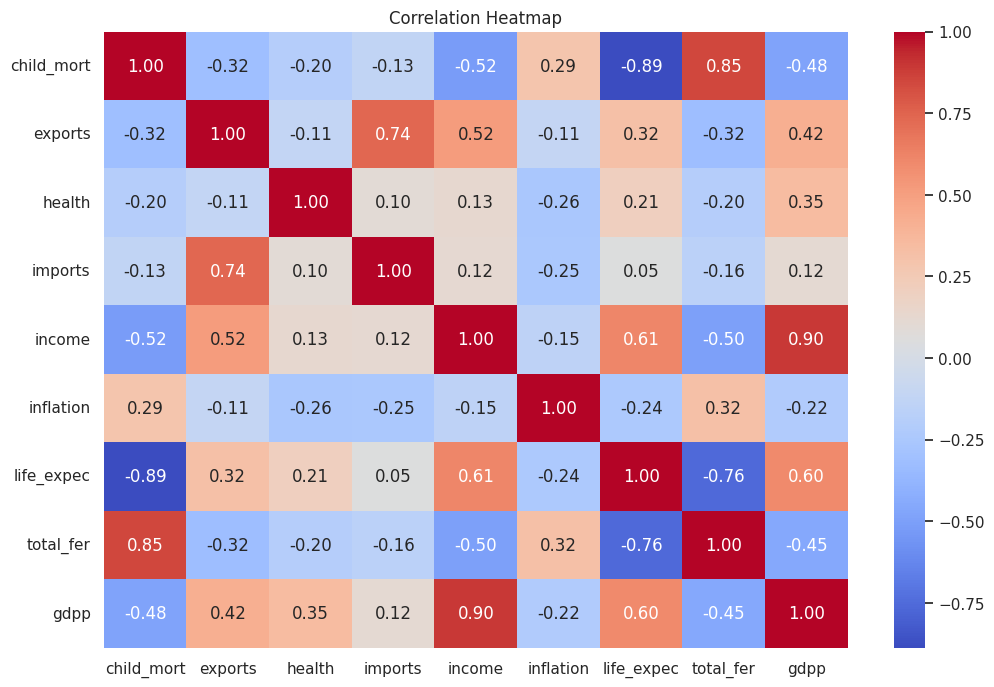

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

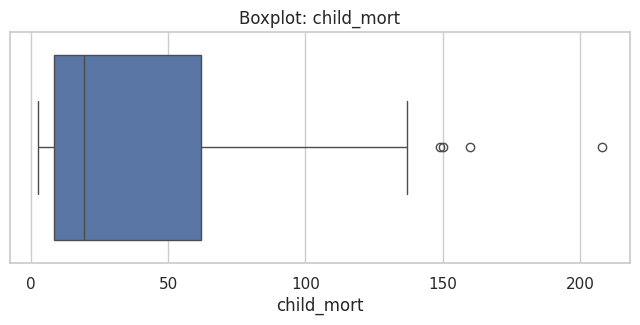

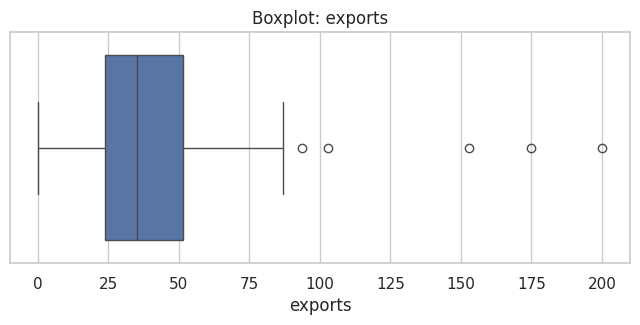

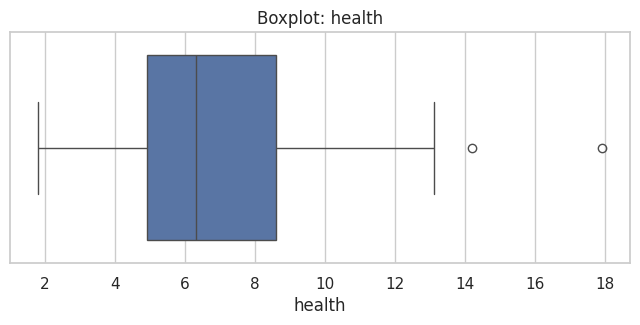

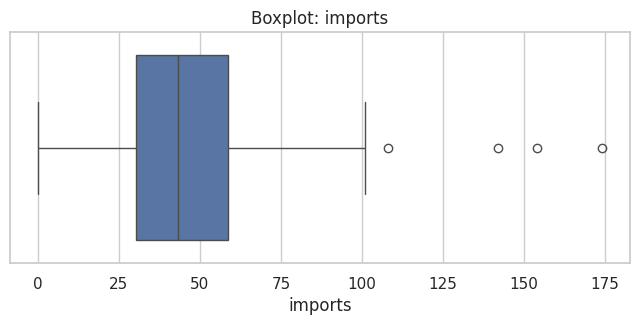

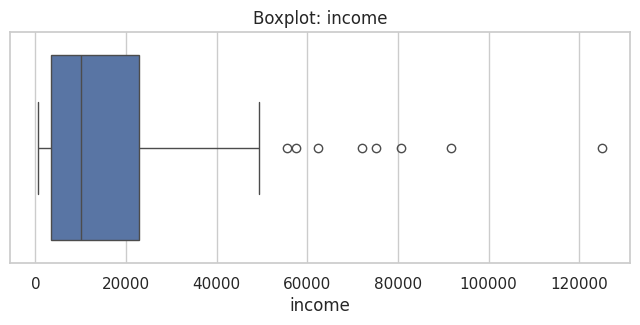

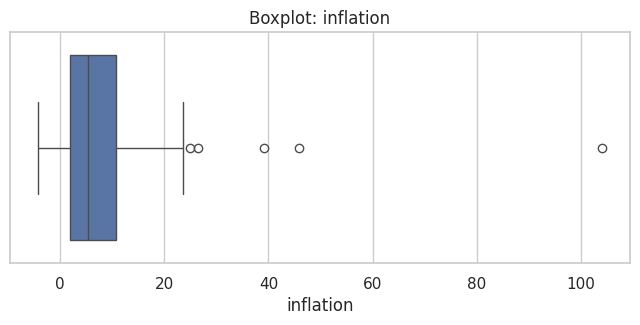

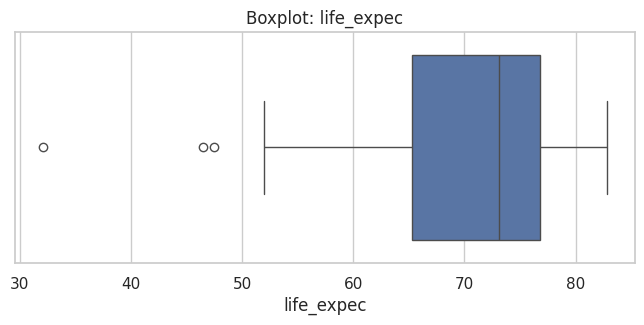

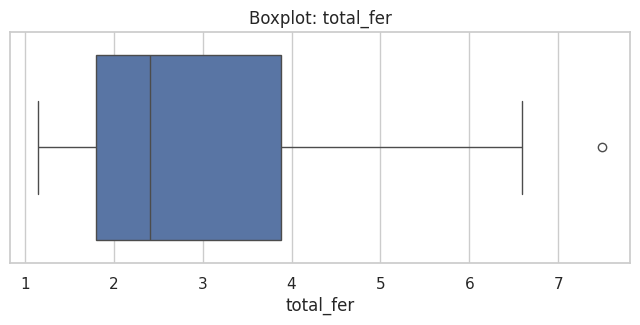

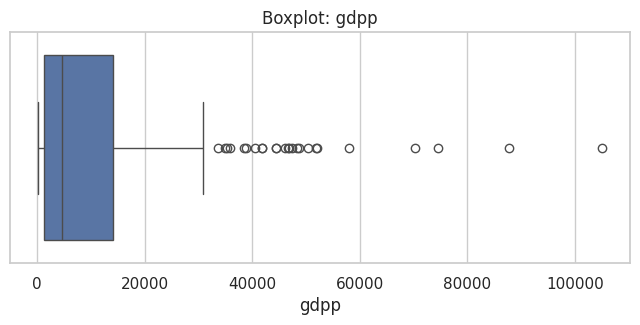

In [9]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

## 8) Feature scaling

Clustering works better when features are on the same scale.

In [10]:
features = df.drop(columns=['country'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.shape

(167, 9)

## 9) K-Means: Elbow method

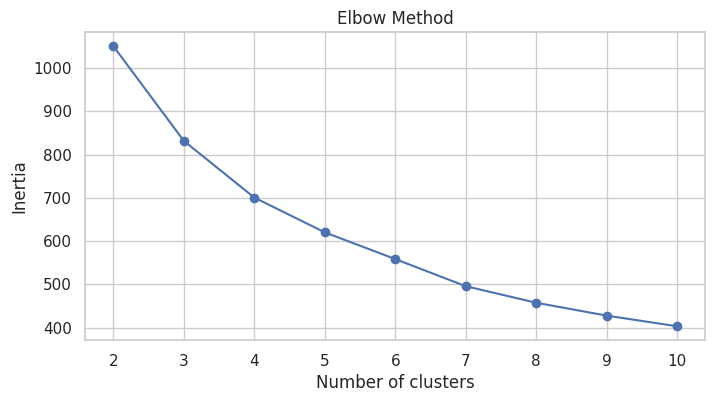

In [11]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

## 10) Train K-Means

In [12]:
best_k = 3  # change after checking the elbow plot
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', silhouette_score(X_scaled, df['kmeans_cluster']))
df[['country', 'kmeans_cluster']].head() if 'country' in df.columns else df[['kmeans_cluster']].head()

Silhouette Score: 0.28329575683463126


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## 11) Try DBSCAN

In [13]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())


dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


## 12) PCA visualization

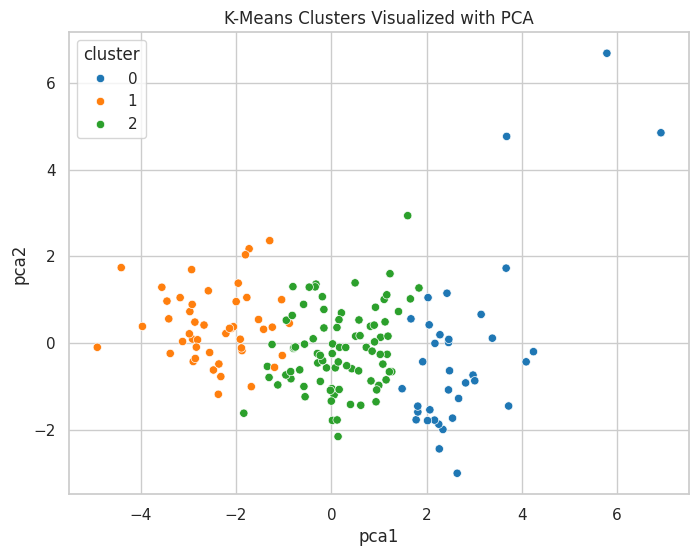

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['kmeans_cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

## 13) Cluster profiling

In [15]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


## 14) Final insights

Write 3 to 5 observations about the clusters:
- Which cluster has high child mortality?

Ans: Cluster 1 has the highest child mortality and fertility rates, along with the lowest life expectancy, indicating that it represents the most underdeveloped countries.
- Which cluster has high income and gdpp?

Ans: Cluster 0 has the highest average income and GDP per capita, as well as the lowest child mortality and highest life expectancy, representing the most developed and economically stable countries.
- Which cluster looks underdeveloped?

Ans: Cluster 2 consists of developing or emerging economies with moderate income, GDP per capita, and health indicators. These countries are progressing but have not yet reached the development level of Cluster 0.
- Which countries should be prioritized for aid?

Ans: Countries belonging to Cluster 1 should be prioritized for international aid and development programs because they face significant challenges in healthcare, education, and economic growth. Improving these areas could substantially enhance their quality of life.

The clustering analysis effectively groups countries based on socio-economic characteristics, enabling policymakers to identify high-risk regions, prioritize resource allocation, and design targeted development strategies.

In [27]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

results = []

def evaluate_model(name, model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results.append([name, acc])

    print("="*60)
    print(name)
    print("="*60)

    print(f"Accuracy : {acc:.4f}\n")

    print(classification_report(
        y_test,
        pred,
        zero_division=0
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        cmap="Blues"
    )

    plt.show()

    return model

prepare data for classification

In [28]:
from sklearn.model_selection import train_test_split

# Features
X = X_scaled

# Target (Pseudo labels generated by K-Means)
y = df['kmeans_cluster']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (133, 9)
Testing Samples : (34, 9)


logistic regression

Logistic Regression
Accuracy : 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



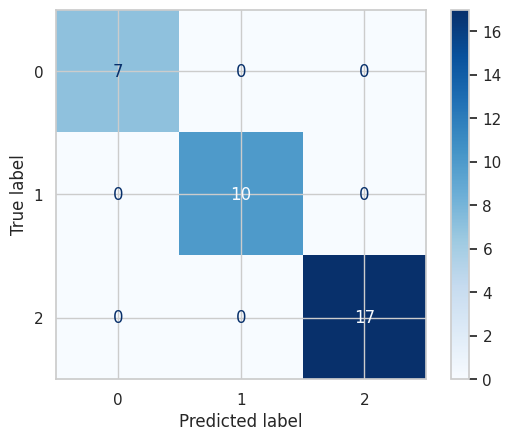

LogisticRegression(max_iter=1000, random_state=42)

In [29]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

evaluate_model(
    "Logistic Regression",
    log_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Naive Bayes

Naive Bayes
Accuracy : 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



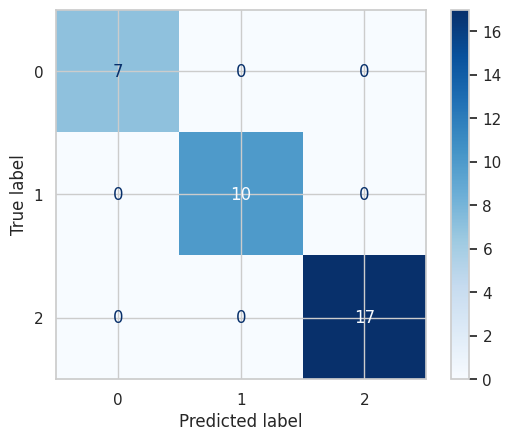

GaussianNB()

In [30]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

evaluate_model(
    "Naive Bayes",
    nb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

K nearest neighbors

KNN
Accuracy : 0.9118

              precision    recall  f1-score   support

           0       1.00      0.57      0.73         7
           1       1.00      1.00      1.00        10
           2       0.85      1.00      0.92        17

    accuracy                           0.91        34
   macro avg       0.95      0.86      0.88        34
weighted avg       0.92      0.91      0.90        34



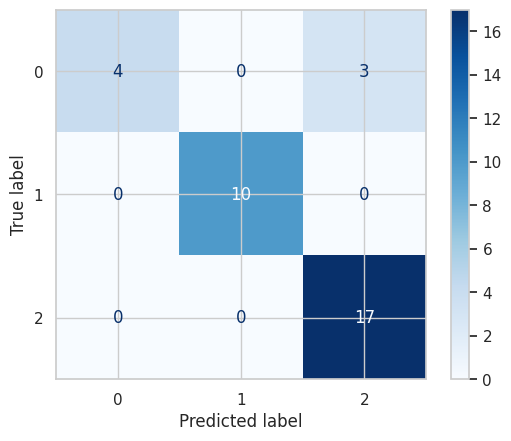

KNeighborsClassifier()

In [31]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

evaluate_model(
    "KNN",
    knn,
    X_train,
    X_test,
    y_train,
    y_test
)

support vector machine

SVM
Accuracy : 0.9706

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      1.00      1.00        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.95      0.96        34
weighted avg       0.97      0.97      0.97        34



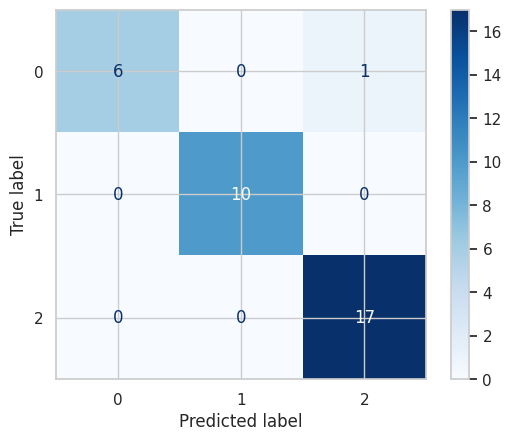

SVC(probability=True, random_state=42)

In [32]:
from sklearn.svm import SVC

svm = SVC(
    probability=True,
    random_state=42
)

evaluate_model(
    "SVM",
    svm,
    X_train,
    X_test,
    y_train,
    y_test
)

Decision tree

Decision Tree
Accuracy : 0.9412

              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.90      0.95        10
           2       0.94      0.94      0.94        17

    accuracy                           0.94        34
   macro avg       0.94      0.95      0.94        34
weighted avg       0.94      0.94      0.94        34



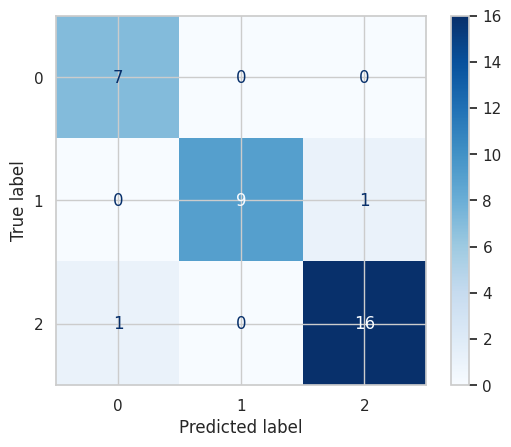

DecisionTreeClassifier(random_state=42)

In [33]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

evaluate_model(
    "Decision Tree",
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

Random forest

Random Forest
Accuracy : 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



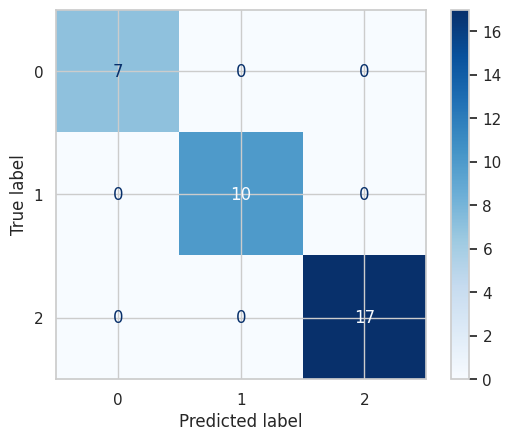

RandomForestClassifier(n_estimators=200, random_state=42)

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

evaluate_model(
    "Random Forest",
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

Feature importance

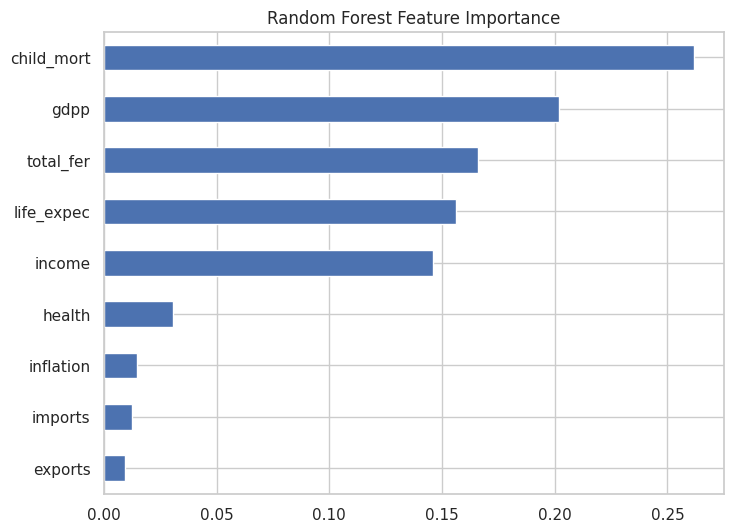

In [35]:
feature_names = df.drop(
    columns=[
        "country",
        "kmeans_cluster",
        "dbscan_cluster"
    ]
).columns

importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Random Forest Feature Importance")

plt.show()

Ada Boost

AdaBoost
Accuracy : 0.9706

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      1.00      1.00        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.95      0.96        34
weighted avg       0.97      0.97      0.97        34



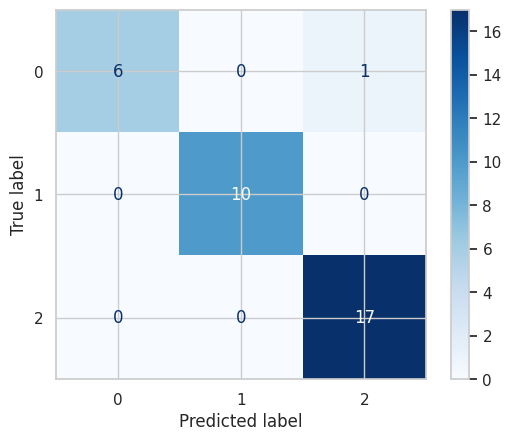

AdaBoostClassifier(random_state=42)

In [36]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    random_state=42
)

evaluate_model(
    "AdaBoost",
    ada,
    X_train,
    X_test,
    y_train,
    y_test
)

Gradient Boosting

Gradient Boosting
Accuracy : 0.9706

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



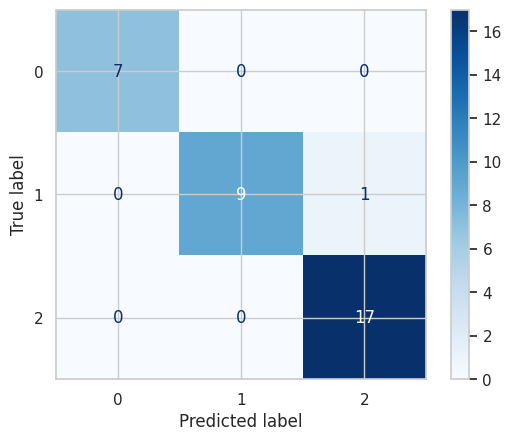

GradientBoostingClassifier(random_state=42)

In [37]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

evaluate_model(
    "Gradient Boosting",
    gb,
    X_train,
    X_test,
    y_train,
    y_test
)

XGBoost

In [38]:
!pip install -q xgboost

XGBoost
Accuracy : 0.9412

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.90      0.95        10
           2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



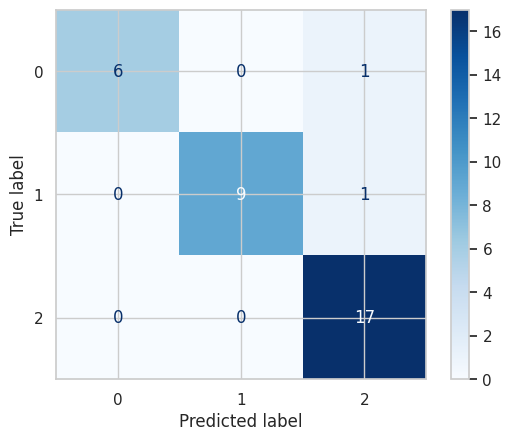

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3, ...)

In [39]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

evaluate_model(
    "XGBoost",
    xgb,
    X_train,
    X_test,
    y_train,
    y_test
)

LightGBM

In [40]:
!pip install -q lightgbm

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
Accuracy : 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



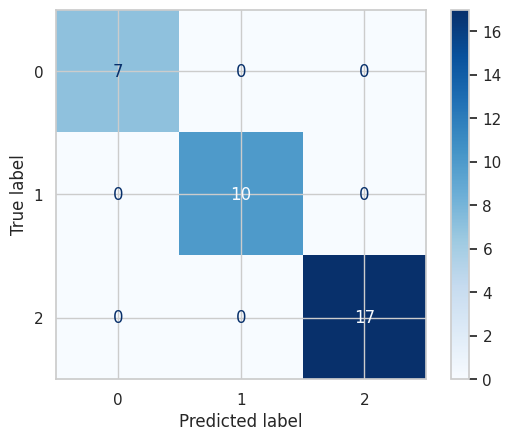

LGBMClassifier(random_state=42, verbose=-1)

In [41]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    random_state=42,
    verbose=-1
)

evaluate_model(
    "LightGBM",
    lgbm,
    X_train,
    X_test,
    y_train,
    y_test
)

Stacking

Stacking
Accuracy : 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



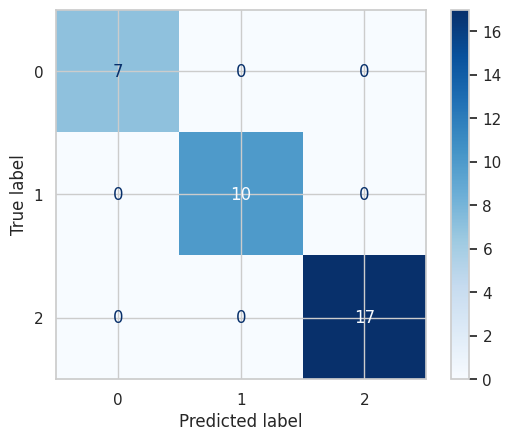

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('knn', KNeighborsClassifier()),
                               ('svm', SVC(probability=True, random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000))

In [42]:
from sklearn.ensemble import StackingClassifier

estimators = [

    ("rf", RandomForestClassifier(random_state=42)),

    ("knn", KNeighborsClassifier()),

    ("svm", SVC(
        probability=True,
        random_state=42
    ))
]

stack = StackingClassifier(

    estimators=estimators,

    final_estimator=LogisticRegression(max_iter=1000),

    cv=5

)

evaluate_model(
    "Stacking",
    stack,
    X_train,
    X_test,
    y_train,
    y_test
)

Model Comparison

In [43]:
comparison = pd.DataFrame(
    results,
    columns=["Model","Accuracy"]
)

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
0,Logistic Regression,1.000000
1,Naive Bayes,1.000000
5,Random Forest,1.000000
9,LightGBM,1.000000
10,Stacking,1.000000
7,Gradient Boosting,0.970588
3,SVM,0.970588
6,AdaBoost,0.970588
4,Decision Tree,0.941176
8,XGBoost,0.941176


Accuracy Graph

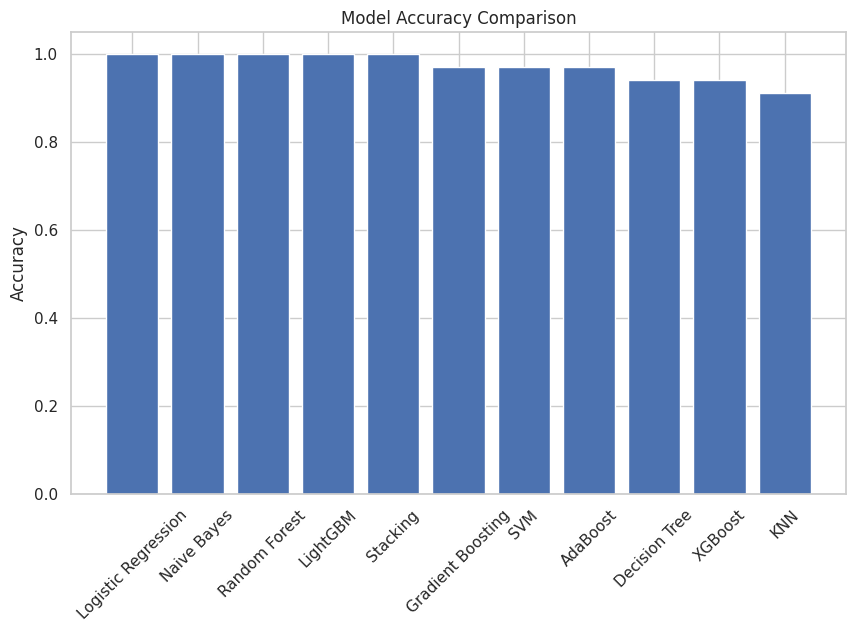

In [44]:
plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()